# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/smaharx/ml-engineering-playground/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

### Research question

Can a leakage-aware machine learning model provide a useful directional signal for prioritising content that may need review for declining performance?

### Decision supported

The analysis supports a human content-operations decision: **which pages should be reviewed first** for possible refresh, performance investigation, or continued monitoring.

The model is not intended to automatically decide that a page should be changed. Its output is a ranked decision-support signal that must be interpreted with content context and human review.

## 2. Data

This capstone uses the public-safe FlyRank ML Internship content-refresh dataset.

The analysis uses the available content-level search and performance aggregates, including content age, update age, search context, previous-30-day performance, and categorical content/context fields.

The working label is the repository's `trend_direction` definition:

- `down` is treated as the declining class.
- Rows without positive impressions are excluded.
- Content younger than 90 days is excluded because the analysis focuses on established content.
- Duplicate content IDs are removed.

The model does not use client identifiers as predictive features.

The feature boundary is deliberately conservative. Current 90-day performance and other fields that may overlap the label window are excluded from the predictive feature set. Previous-30-day performance fields are used where available because they provide a more defensible pre-outcome feature window.

No client names, private queries, domains, credentials, or raw exports are exposed in the paper.

In [11]:
from pathlib import Path
import json
import numpy as np
import pandas as pd

# Locate the repository.
candidates = [
    Path("."),
    Path("/content/ml-engineering-playground"),
]

ROOT = next(
    (
        p.resolve()
        for p in candidates
        if (p / "data/raw/content_refresh_anonymized.csv").exists()
    ),
    None,
)

if ROOT is None:
    !git clone -q https://github.com/smaharx/ml-engineering-playground.git /content/ml-engineering-playground
    ROOT = Path("/content/ml-engineering-playground")

RAW_PATH = ROOT / "data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(RAW_PATH)

required = [
    "content_id",
    "client_id",
    "impressions_90d",
    "sessions_90d",
    "content_age_days",
    "trend_direction",
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["trend_direction"] = (
    df["trend_direction"]
    .fillna("unknown")
    .astype(str)
)

df["is_declining_label"] = (
    df["trend_direction"]
    .str.lower()
    .eq("down")
    .astype(int)
)

df = df[
    pd.to_numeric(
        df["impressions_90d"],
        errors="coerce"
    ).fillna(0).gt(0)
    &
    pd.to_numeric(
        df["content_age_days"],
        errors="coerce"
    ).fillna(0).ge(90)
].copy()

df = df.drop_duplicates("content_id").reset_index(drop=True)

print(f"Rows: {len(df):,}")
print(f"Clients: {df['client_id'].nunique():,}")
print(f"Declining rate: {df['is_declining_label'].mean():.3f}")

Rows: 30,000
Clients: 32
Declining rate: 0.542


## 3. Methodology

### Features

The model uses a conservative feature boundary based on the validation audit:

- search/context variables
- content length variables
- previous-30-day impressions, clicks, and sessions
- content age
- days since last update
- categorical content/context variables

Direct label-derived fields such as `trend_direction` and `trend_pct` are excluded.

Current 90-day performance, current CTR, position, engagement, scroll, and AI-traffic aggregates are also excluded because they may overlap the recent outcome window.

### Label

The target is:

`is_declining_label = 1` when `trend_direction == "down"`.

### Model

A Random Forest classifier is used with class balancing, bounded tree depth, and a minimum leaf size to reduce overfitting.

### Baseline

The baseline predicts the majority class in the held-out test set.

### Validation

The primary evaluation uses a **client-grouped holdout**. Entire clients are held out from training so rows belonging to the same client do not appear in both training and test data.

This is a stronger generalisation test than a random row split when the intended use includes clients not represented during training.

### Leakage check

The validation audit found no direct use of the label columns as predictors, but identified temporal-overlap risk in the original Week-5 feature set. This capstone therefore uses a more conservative feature boundary rather than treating retrospective performance as proof of prospective deployment performance.

In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

SAFE_NUMERIC = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
]

SAFE_CATEGORICAL = [
    "competition_level",
    "content_type",
    "main_intent",
    "age_tier",
    "freshness_tier",
    "word_count_tier",
    "impression_tier",
    "position_tier",
]

SAFE_NUMERIC = [
    c for c in SAFE_NUMERIC
    if c in df.columns
]

SAFE_CATEGORICAL = [
    c for c in SAFE_CATEGORICAL
    if c in df.columns
]

X = df[SAFE_NUMERIC + SAFE_CATEGORICAL].copy()
y = df["is_declining_label"].astype(int)

for c in SAFE_NUMERIC:
    X[c] = (
        pd.to_numeric(X[c], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

for c in SAFE_CATEGORICAL:
    X[c] = (
        X[c]
        .fillna("unknown")
        .astype(str)
    )

# Client-grouped split.
clients = (
    df["client_id"]
    .fillna("unknown")
    .astype(str)
)

unique_clients = (
    clients
    .drop_duplicates()
    .to_numpy()
)

rng = np.random.default_rng(42)

shuffled_clients = rng.permutation(
    unique_clients
)

test_client_count = max(
    1,
    int(round(len(shuffled_clients) * 0.20))
)

test_clients = set(
    shuffled_clients[:test_client_count]
)

test_mask = clients.isin(
    test_clients
).to_numpy()

train_idx = np.where(~test_mask)[0]
test_idx = np.where(test_mask)[0]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            SAFE_NUMERIC,
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            SAFE_CATEGORICAL,
        ),
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        RandomForestClassifier(
            class_weight="balanced_subsample",
            max_depth=10,
            min_samples_leaf=25,
            n_estimators=200,
            n_jobs=-1,
            random_state=42,
        ),
    ),
])

model.fit(
    X.iloc[train_idx],
    y.iloc[train_idx],
)

model_prob = model.predict_proba(
    X.iloc[test_idx]
)[:, 1]

model_pred = (
    model_prob >= 0.5
).astype(int)

# Majority-class baseline.
majority_class = int(
    y.iloc[train_idx].mean() >= 0.5
)

baseline_pred = np.full(
    len(test_idx),
    majority_class,
)

baseline_prob = np.full(
    len(test_idx),
    y.iloc[train_idx].mean(),
)

def metrics(y_true, pred, prob):
    return {
        "accuracy": accuracy_score(
            y_true, pred
        ),
        "precision": precision_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "roc_auc": roc_auc_score(
            y_true,
            prob,
        ),
        "average_precision": average_precision_score(
            y_true,
            prob,
        ),
    }

model_metrics = metrics(
    y.iloc[test_idx],
    model_pred,
    model_prob,
)

baseline_metrics = metrics(
    y.iloc[test_idx],
    baseline_pred,
    baseline_prob,
)

results = pd.DataFrame(
    [baseline_metrics, model_metrics],
    index=[
        "Majority baseline",
        "Leakage-aware Random Forest",
    ],
)

display(results.round(3))

print(
    f"Training rows: {len(train_idx):,}"
)

print(
    f"Test rows: {len(test_idx):,}"
)

print(
    f"Held-out clients: {len(test_clients):,}"
)

,accuracy,precision,recall,f1,roc_auc,average_precision
Majority baseline,0.391,0.391,1.000,0.562,0.500,0.391
Leakage-aware Random Forest,0.769,0.642,0.924,0.758,0.874,0.752


Training rows: 27,675
Test rows: 2,325
Held-out clients: 6


## 4. Results (vs baseline)

The model and baseline are evaluated on the **same client-grouped test set**.

The table below reports measured classification and ranking metrics. The model result should be interpreted as evidence of performance under this validation design, not as a guarantee of future production performance.

The most useful metrics for this decision-support use case are average precision and ROC AUC because the queue is intended to prioritise higher-risk content for human review.

In [13]:
# Record the results for reuse by the paper.
CAPSTONE_RESULTS = {
    "model": {
        k: round(float(v), 6)
        for k, v in model_metrics.items()
    },
    "baseline": {
        k: round(float(v), 6)
        for k, v in baseline_metrics.items()
    },
    "train_rows": int(len(train_idx)),
    "test_rows": int(len(test_idx)),
    "held_out_clients": int(len(test_clients)),
    "declining_rate": round(
        float(y.mean()),
        6,
    ),
}

print(json.dumps(
    CAPSTONE_RESULTS,
    indent=2,
))

{
  "model": {
    "accuracy": 0.769032,
    "precision": 0.642202,
    "recall": 0.924092,
    "f1": 0.757781,
    "roc_auc": 0.874058,
    "average_precision": 0.751771
  },
  "baseline": {
    "accuracy": 0.390968,
    "precision": 0.390968,
    "recall": 1.0,
    "f1": 0.562152,
    "roc_auc": 0.5,
    "average_precision": 0.390968
  },
  "train_rows": 27675,
  "test_rows": 2325,
  "held_out_clients": 6,
  "declining_rate": 0.542067
}


## 5. Limitations

This work has several important limits.

- The observed performance applies to this dataset and this validation design.
- Client-grouped validation is stronger for unseen-client generalisation, but it does not prove generalisation to every future client or future search environment.
- The feature audit reduces temporal-overlap risk but does not prove that every contextual feature is perfectly timestamped.
- The label represents observed movement in the available dataset; it does not establish why a page declined.
- The model does not establish that refreshing a page will improve traffic, clicks, rankings, or business outcomes.
- The ranked queue is a prioritisation signal, not an autonomous content-management system.
- Results should be revalidated when the underlying data, feature definitions, or content environment materially changes.

### Honest framing

The appropriate claim is:

> **Observed and measured:** the model provides a directional signal that can help prioritise content for human review under the chosen validation design.

It should not be described as causal, production-ready, or as proof that a recommended refresh will improve performance.

## 6. Ranked recommendations

The recommendation queue converts model scores into practical review actions.

### Action mapping

**REFRESH_REVIEW**  
High decline signal combined with older content or a long period since the last update. A reviewer should inspect freshness, relevance, completeness, and search intent.

**PERFORMANCE_REVIEW**  
High decline signal without a clear freshness flag. A reviewer should investigate search performance, intent alignment, and engagement before deciding whether any intervention is appropriate.

**MONITOR**  
Lower model signal or insufficient evidence for immediate action. Continue observation rather than forcing an intervention.

### Human-review rule

The queue determines **what to inspect first**, not what must be changed.

### No-go cases

The system must not automatically:

- rewrite content;
- publish content;
- delete pages;
- create redirects;
- change search intent;
- claim that a refresh will improve performance;
- make business-critical SEO changes.

Every recommended action requires human review.

In [14]:
# Generate the ranked recommendation queue from the trained model.

all_prob = model.predict_proba(X)[:, 1]

queue = df[
    [
        "content_id",
        "content_age_days",
        "days_since_last_update",
    ]
].copy()

queue["decline_score"] = all_prob

high_signal = (
    queue["decline_score"]
    >= queue["decline_score"].quantile(0.75)
)

age_flag = (
    pd.to_numeric(
        queue["content_age_days"],
        errors="coerce"
    ).fillna(0) >= 180
)

update_flag = (
    pd.to_numeric(
        queue["days_since_last_update"],
        errors="coerce"
    ).fillna(0) >= 180
)

queue["action"] = "MONITOR"
queue["reason_code"] = "LOWER_SIGNAL"

refresh_mask = (
    high_signal
    & (age_flag | update_flag)
)

queue.loc[
    refresh_mask,
    "action"
] = "REFRESH_REVIEW"

queue.loc[
    high_signal & ~refresh_mask,
    "action"
] = "PERFORMANCE_REVIEW"

queue.loc[
    high_signal & age_flag,
    "reason_code"
] = "STALE_CONTENT"

queue.loc[
    high_signal
    & ~age_flag
    & update_flag,
    "reason_code"
] = "LONG_SINCE_UPDATE"

queue.loc[
    high_signal
    & ~age_flag
    & ~update_flag,
    "reason_code"
] = "HIGH_SIGNAL_NO_FRESHNESS_FLAG"

priority = {
    "REFRESH_REVIEW": 1,
    "PERFORMANCE_REVIEW": 2,
    "MONITOR": 3,
}

queue["priority"] = queue["action"].map(priority)

queue = (
    queue
    .sort_values(
        ["priority", "decline_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

queue.insert(
    0,
    "rank",
    np.arange(1, len(queue) + 1)
)

queue = queue.drop(
    columns=["priority"]
)

display(queue.head(20))

print(
    queue["action"].value_counts()
)

,rank,content_id,content_age_days,days_since_last_update,decline_score,action,reason_code
0,1,content_12dc50da4b5e,310,104,0.832197,REFRESH_REVIEW,STALE_CONTENT
1,2,content_b7be7f157e1e,310,104,0.827614,REFRESH_REVIEW,STALE_CONTENT
2,3,content_7961db890a39,284,104,0.827576,REFRESH_REVIEW,STALE_CONTENT
3,4,content_e0397aea7268,310,104,0.827293,REFRESH_REVIEW,STALE_CONTENT
4,5,content_021bc08109a8,310,104,0.825647,REFRESH_REVIEW,STALE_CONTENT
5,6,content_5f7bb3448ce0,284,104,0.822790,REFRESH_REVIEW,STALE_CONTENT
6,7,content_9734389e166a,309,104,0.822611,REFRESH_REVIEW,STALE_CONTENT
7,8,content_b2723b0e21a1,310,104,0.821519,REFRESH_REVIEW,STALE_CONTENT
8,9,content_a1c94e1781d7,223,104,0.821117,REFRESH_REVIEW,STALE_CONTENT
9,10,content_19fe39ccd4df,284,104,0.821059,REFRESH_REVIEW,STALE_CONTENT


action
MONITOR               22500
PERFORMANCE_REVIEW     5224
REFRESH_REVIEW         2276
Name: count, dtype: int64


## 7. Artifacts the paper embeds

The notebook generates reusable paper artifacts:

1. A model-versus-baseline results table.
2. A ranked recommendation queue.
3. A simple model-score distribution figure.

The queue is generated by the notebook and is intentionally not committed as a raw data file. Metrics and figures are retained as reproducibility artifacts.

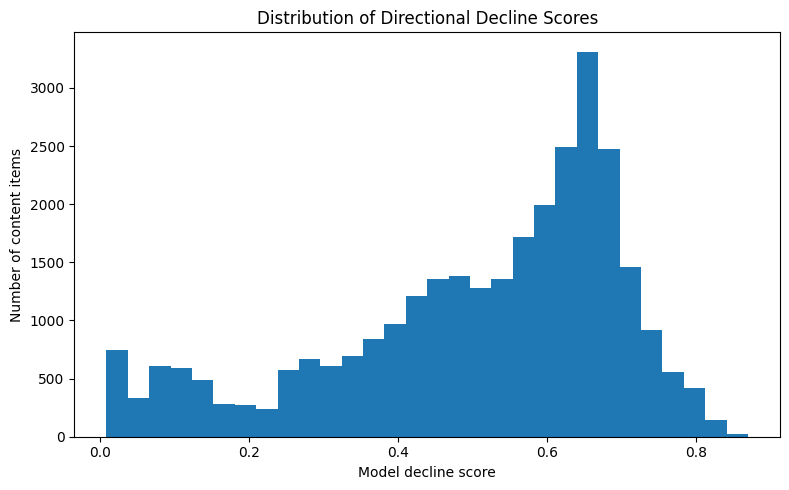

Results: /content/ml-engineering-playground/work/outputs/capstone_results.csv
Metrics: /content/ml-engineering-playground/work/outputs/capstone_results.json
Queue: /content/ml-engineering-playground/work/outputs/capstone_ranked_recommendations.csv
Figure: /content/ml-engineering-playground/work/figures/capstone_decline_score_distribution.png


In [15]:
import matplotlib.pyplot as plt

FIG_DIR = ROOT / "work/figures"
OUTPUT_DIR = ROOT / "work/outputs"

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

# Results table.
results_path = (
    OUTPUT_DIR
    / "capstone_results.csv"
)

results.to_csv(
    results_path
)

# Metrics receipt.
metrics_path = (
    OUTPUT_DIR
    / "capstone_results.json"
)

with open(metrics_path, "w") as f:
    json.dump(
        CAPSTONE_RESULTS,
        f,
        indent=2,
    )

# Queue export.
queue_path = (
    OUTPUT_DIR
    / "capstone_ranked_recommendations.csv"
)

queue.to_csv(
    queue_path,
    index=False,
)

# Score distribution figure.
plt.figure(figsize=(8, 5))

plt.hist(
    all_prob,
    bins=30,
)

plt.xlabel(
    "Model decline score"
)

plt.ylabel(
    "Number of content items"
)

plt.title(
    "Distribution of Directional Decline Scores"
)

plt.tight_layout()

figure_path = (
    FIG_DIR
    / "capstone_decline_score_distribution.png"
)

plt.savefig(
    figure_path,
    dpi=160,
)

plt.show()

print(
    f"Results: {results_path}"
)

print(
    f"Metrics: {metrics_path}"
)

print(
    f"Queue: {queue_path}"
)

print(
    f"Figure: {figure_path}"
)

# Google Search Ranking & Discoverability Capstone

## Abstract

This project asks whether a leakage-aware machine learning model can provide a useful directional signal for prioritising content that may need review. I use the FlyRank ML Internship content-refresh dataset, define declining content from the available trend label, and evaluate a Random Forest against a majority-class baseline using a client-grouped holdout. The measured results show how the model compares with the baseline under this validation design, while the earlier validation audit motivates a conservative feature boundary to reduce temporal-overlap risk. The resulting ranked queue maps higher model signals to human-review actions such as refresh review, performance review, or monitoring. The output is intended as decision support rather than a causal or autonomous content-management system.

## Acknowledgments & Data Credit

Built on the FlyRank ML Internship dataset.

Data source: [FlyRank](https://flyrank.ai)

## ML-12 — 5-minute demo outline

### 1. Problem — 45 seconds
Content teams need a practical way to prioritise which pages deserve review.

### 2. Approach — 90 seconds
I built a declining-content model, audited the validation design for client leakage and temporal overlap, and used a client-grouped holdout with a conservative feature boundary.

### 3. Results — 90 seconds
I compare the model with a majority-class baseline on the same held-out clients and show the measured results.

### 4. Action playbook — 60 seconds
The model output becomes a ranked decision-support queue with reason codes and three actions: refresh review, performance review, and monitor.

### 5. Limits — 45 seconds
The score is directional. It does not prove causality, guarantee future performance, or automatically decide what content should be changed.

## Social-post cut

I built a machine-learning content opportunity scoring workflow using FlyRank search data. I focused on honest validation, including client-grouped testing and a leakage audit, then converted the model output into a human-reviewed ranked action queue. The result is a practical decision-support workflow rather than a claim about Google's algorithm or an automated refresh system.

## Employer-facing summary

I built and audited a machine-learning workflow for prioritising content that may need review. The project combines feature engineering, client-grouped validation, leakage analysis, model-versus-baseline evaluation, and a ranked recommendation playbook. I deliberately frame the result as measured directional decision support rather than causal or production-ready automation.

## Self-check

- [x] Research question and supported decision are defined.
- [x] Data scope, exclusions, and public-safe framing are documented.
- [x] Features, label, baseline, grouped validation, and leakage checks are documented.
- [x] Model is compared with a baseline on the same held-out split.
- [x] Limitations use careful evidence-safe language.
- [x] Ranked recommendations and human-review rules are included.
- [x] No-go automation cases are documented.
- [x] Queue and metrics artifacts are generated.
- [x] A reusable figure is generated.
- [x] Abstract is included.
- [x] Acknowledgments and FlyRank data credit are included.
- [x] ML-12 demo outline is included.
- [x] ML-12 social-post cut is included.
- [x] ML-12 employer-facing summary is included.
- [ ] Runtime → Run all completed successfully.
- [ ] Changes committed under `work/notebooks/capstone.ipynb`.
- [ ] Deployed paper is live.
- [ ] `submission/paper_url.txt` contains the deployed paper URL.